In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# как оказалось, pytorch в качестве ускорителя по умолчанию использует cpu, и для того
# ускорить обучение лучше переключить на графические процессоры nvidia

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [ ]:
from torchvision import datasets
from torchvision.transforms import ToTensor

# сразу решил откалибровать данные через ToTensor, чтобы значения были в диапазоне от 0.0 до 1.0
train_data = datasets.MNIST(root='mnist', download=True, train=True, transform=ToTensor()) # для обучения
test_data = datasets.MNIST(root='mnist', download=True, train=False, transform=ToTensor()) # для тестинга

train_data.data.shape, test_data.data.shape

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]


Extracting mnist/MNIST/raw/train-images-idx3-ubyte.gz to mnist/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]


Extracting mnist/MNIST/raw/train-labels-idx1-ubyte.gz to mnist/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 4.43MB/s]


Extracting mnist/MNIST/raw/t10k-images-idx3-ubyte.gz to mnist/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 8.89MB/s]

Extracting mnist/MNIST/raw/t10k-labels-idx1-ubyte.gz to mnist/MNIST/raw



(torch.Size([60000, 28, 28]), torch.Size([10000, 28, 28]))

In [ ]:
!pip install torchinfo

In [ ]:
from torch import nn

class NumberClassifier(nn.Module):
  def __init__(self, hidden_neurons, dropout):
      super().__init__()
      self.flatten = nn.Flatten() # (256, 1, 28, 28) -> (256, 784)
      in_features = 784 # 28x28 фото
      self.model = nn.Sequential()

      for out_features in hidden_neurons: # чтобы затестить модель на разных количествах нейронов и слоев
        self.model.append(nn.Linear(in_features, out_features))
        self.model.append(nn.BatchNorm1d(out_features)) # для сжатия данных
        self.model.append(nn.ReLU()) # функция активации
        self.model.append(nn.Dropout(dropout)) # борьба с overfitting'ом
        in_features = out_features

      self.model.append(nn.Linear(in_features, 10))

  def forward(self, x):
    x = self.flatten(x)
    x = self.model(x)
    return x


# Выведем summary модели

from torchinfo import summary

sample_model = NumberClassifier(hidden_neurons=[512, 256, 128, 64, 32, 10], dropout=0.2).to(device)
print(summary(sample_model, input_size=(1, 1, 28, 28)))
del sample_model # чтоб не занимало память на VRAM
torch.cuda.empty_cache()
#print(next(sample_model.parameters()).device)

Layer (type:depth-idx)                   Output Shape              Param #
NumberClassifier                         [1, 10]                   --
├─Flatten: 1-1                           [1, 784]                  --
├─Sequential: 1-2                        [1, 10]                   --
│    └─Linear: 2-1                       [1, 512]                  401,920
│    └─BatchNorm1d: 2-2                  [1, 512]                  1,024
│    └─ReLU: 2-3                         [1, 512]                  --
│    └─Dropout: 2-4                      [1, 512]                  --
│    └─Linear: 2-5                       [1, 256]                  131,328
│    └─BatchNorm1d: 2-6                  [1, 256]                  512
│    └─ReLU: 2-7                         [1, 256]                  --
│    └─Dropout: 2-8                      [1, 256]                  --
│    └─Linear: 2-9                       [1, 128]                  32,896
│    └─BatchNorm1d: 2-10                 [1, 128]                  

In [ ]:
# сразу подготовим несколько архитектур чтобы их затестить, одновременно перенося их на GPU

architectures = [
    ("Small Model", NumberClassifier(hidden_neurons=[128, 64, 10], dropout=0.1).to(device)),
    ("Medium Model", NumberClassifier(hidden_neurons=[256, 128, 64, 10], dropout=0.1).to(device)),
    ("Large Model", NumberClassifier(hidden_neurons=[512, 256, 128, 64, 32, 10], dropout=0.1).to(device)),
] # при использовании dropout >= 0.2, модели Small и Medium показывали <= 98.00% Accuracy, поэтому решил изменить на 0.1 как было изначально у модели Large.
# Это улучшило показатели.


from torch.utils.data import DataLoader
import os
# разделим данные на батчи
batch_size = 256
num_of_epochs = 100
num_workers = min(8, os.cpu_count()) # для многопоточности
train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True, persistent_workers=True) # обучающая выборка
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True, persistent_workers=True) # тестовая выборка
# persistent_workers позволяет переиспользовать потоки
# pinned_memory позволяет использовать область памяти ОЗУ которая не выгружает ее в виртуальную


In [ ]:
# напишем функцию обучения модели чтобы вызывать ее для разных конфигураций
from torch import optim

def train_model(model, dataloader, optimizer=None):
  if optimizer == None:
    model.eval()
  else:
    model.train()
  loss_function = nn.CrossEntropyLoss()
  """Кросс-энтропийная функция ошибки, по началу хотел использовать BCEloss,
  но чтобы его корректно использовать пришлось бы использовать onehotencoding
  который в свою очередь использовал еще больше памяти. Вообщем данный вариант,
  оказался самым удобным и быстрым"""
  total_loss = 0

  for X, y in dataloader:
    X, y = X.to(device), y.to(device) # перенесем все данные в видеопамять
    pred = model(X)
    loss = loss_function(pred, y)
    total_loss += loss
    if optimizer != None:
      optimizer.zero_grad() # обнуляем градиенты
      loss.backward() # backpropagation
      optimizer.step() # пересчитываем веса

  total_loss = total_loss.item()
  return total_loss / len(dataloader)


In [ ]:
from IPython.display import clear_output

def show_losses(train_loss_hist, test_loss_hist): # визуализация
    clear_output()

    plt.figure(figsize=(12,4))

    plt.subplot(1, 2, 1)
    plt.title('Train Loss')
    plt.plot(np.arange(len(train_loss_hist)), train_loss_hist)
    plt.yscale('log')
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.title('Test Loss')
    plt.plot(np.arange(len(test_loss_hist)), test_loss_hist)
    plt.yscale('log')
    plt.grid()

    plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, dataloader, device): # посчитаем все метрики
    model.eval()

    y_true, y_pred = [], []

    with torch.no_grad():
        for X, y in dataloader:

            X, y = X.to(device), y.to(device)
            pred = model(X)

            y_pred.append(torch.argmax(pred, dim=1)) # индекс, наиболее вероятного класса
            y_true.append(y)

    y_pred = torch.cat(y_pred).cpu().numpy() # переносим из VRAM в RAM
    y_true = torch.cat(y_true).cpu().numpy()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro') # найдем среднее классов для всех метрик
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    return accuracy, precision, recall, f1

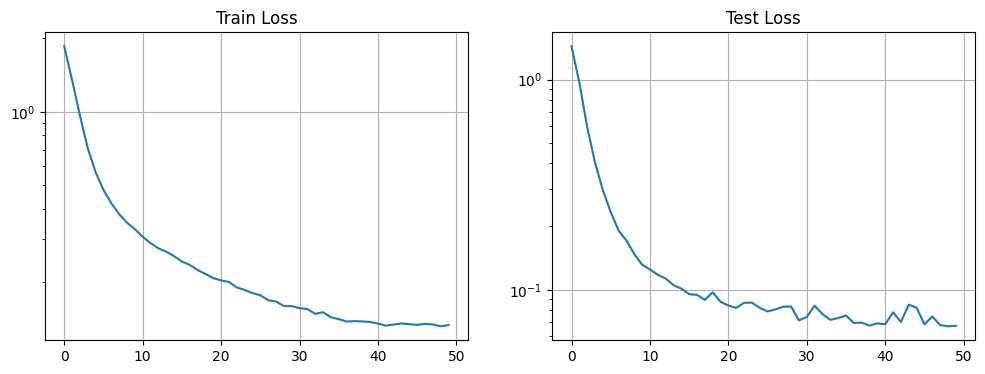

In [ ]:
# теперь проведем пару экспериментов и выясним какая конфигурация лучше
import pandas as pd
from torch.optim.lr_scheduler import ReduceLROnPlateau

experiments = []

for name, model in architectures:
    print(f"Current training model: {name}...")
    if torch.cuda.device_count() > 1:
        model = torch.nn.DataParallel(model) # распараллеливание работы между GPU
    best_avg_error = float('inf')
    patience, epochs_without_improvement, best_epoch = 10, 0, 0 # 10 эпох без улучшений = выход из цикла
    optimizer = optim.SGD(model.parameters(), lr=0.01)

    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5) # позволяет каждый раз изменять lr при застыве модели (проверка каждыe patience эпох)

    train_loss_hist = []
    test_loss_hist = []
    for i in range(num_of_epochs):
        train_loss = train_model(model, train_dataloader, optimizer=optimizer) # обучение
        train_loss_hist.append(train_loss)
        test_loss = train_model(model, test_dataloader) # тестинг
        test_loss_hist.append(test_loss)

        if i % 10 == 9:
          show_losses(train_loss_hist, test_loss_hist) # отображаем промежуточные результаты

        if test_loss < best_avg_error: # проверяем есть ли какие-либо улучшения
            best_avg_error = test_loss
            best_epoch = i # сразу отмечаем лучшую эпоху
            epochs_without_improvement = 0 # обнуляем, т.к было улучшение
        else:
            epochs_without_improvement += 1 # нету улучшений

        if epochs_without_improvement >= patience: # если нету улучшений и уже прошло >= 10 эпох то выходим из цикла
            train_loss_hist = train_loss_hist[:best_epoch+1] # историю оставляем только до лучшей эпохи
            test_loss_hist = test_loss_hist[:best_epoch+1]
            break

        scheduler.step(test_loss) # меняет lr в зависимости от поведения модели при застыве (проверка каждыe patience эпох)

    acc, prec, rec, f1 = evaluate_model(model, test_dataloader, device) # еще раз тестим чтобы получить метрики
    experiments.append({
        "Experiment": name,
        "Min Validation Loss": best_avg_error,
        "Best Epoch": best_epoch,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    }) # сохраняем конфигурации модели

    del model
    torch.cuda.empty_cache() # освобождаем VRAM


#**Мои наблюдения:**

Модель 1 ("Small Model") показывает быстрое и плавное снижение как на обучающей, так и на тестовой выборке. На первых 10 эпохах наблюдается резкое падение функции потерь, что говорит о быстром обучении и корректировке весов. К 20-й эпохе снижение продолжается, но уже более плавно, без резких скачков.В районе 30 – 40-й эпохи кривая обучения становится более шумной, однако сохраняется уменьшение ошибки. К 50-й эпохе модель достигает довольно низкого значения потерь, при этом заметно, что и на тестовых данных потери остаются стабильными и невысокими.
С 50-й по 100-ю эпоху видно дальнейше, хоть и более медленное, улучшение.

Модель 2 ("Medium Model") показывает более быстрый спад функции потерь по сравнению с "Small Model", особенно на первых 10 эпохах. С 1-й по 10-ю эпоху заметен резкий спад и на обучающей, и на тестовой выборке, что говорит о быстром обучении. К 20-й эпохе функция потерь продолжает убывать, но уже не так стремительно, что может говорить о том, что модель приблизилась к области пика. На 30-й эпохе можно наблюдать небольшие колебания на тестовой выборке, однако в общем функция продолжает убывать. К 40-й эпохе модель сохраняет стабильное снижение ошибки, колебания становятся менее заметными. На 50-й эпохе видно, что модель всё ещё улучшается: ошибка в обучающей выборке продолжает плавно снижаться, а тестовая держится на относительно низком уровне с небольшими колебаниями. К 60-й эпохе функция потерь на обучающей выборке достигает ещё более низких значений и достигает своего пика.

Модель 3 ("Large Model") имеет схожую динамику изменений с 1 и 2 моделью. К 50-й эпохе модель достигает достаточно низкого уровня потерь на обучающей выборке, а тестовая ошибка стабилизируется с небольшими колебаниями. Нет явных признаков переобучения.

In [ ]:
report = pd.DataFrame(experiments)

print(report)  # отчет

     Experiment  Min Validation Loss  Best Epoch  Accuracy  Precision  \
0   Small Model             0.064694          92    0.9809   0.980879   
1  Medium Model             0.054858          56    0.9846   0.984571   
2   Large Model             0.066975          48    0.9831   0.983093   

     Recall  F1-score  
0  0.980806  0.980830  
1  0.984515  0.984537  
2  0.982910  0.982991  


# **Выводы:**
Лучший результат показала Medium Model, которая достигла самой низкой ошибки на валидации и наивысших значений метрик (точности, precision, recall, f1-score). Она была средним между двумя моделями, и это позволило ей быть более сбалансированной по сложности и размеру слоёв, при этом не теряя в точности (98.46%).

Small Model дала стабильный результат с 98.09% точности, но её обучение потребовало все 100 эпох, что может указывать на её склонность к долгому обучению или недостаточную сложность архитектуры для данной задачи.

Large Model показала хорошие результаты, но её слишком высокая сложность не принесла значительного улучшения по сравнению с Medium Model. Количество слоев, нейронов по-моему мнению, должны были сделать эту модель наиболее точной среди них, однако везде необходим баланс. Несмотря на это, её результаты остаются на высоком уровне и вполне конкурентоспособными.





# **Отчет:**

| Experiment      | Min Validation Loss | Best Epoch | Accuracy | Precision | Recall  | F1-score |
|-----------------|---------------------|------------|----------|-----------|---------|----------|
| Small Model     | 6.47%               | 92         | 98.09%   | 98.09%    | 98.08%  | 98.08%   |
| Medium Model    | 5.49%               | 56         | 98.46%   | 98.46%    | 98.45%  | 98.45%   |
| Large Model     | 6.70%               | 48         | 98.31%   | 98.31%    | 98.29%  | 98.30%   |
